# ETS MARL — Data Science Analysis

Implements the analyses described in `planning/data_science_analysis_plan.md`
(v3). Every section ties back to a specific thesis claim. The structure is:

| § | Analysis | Claim | Methods |
|---|---|---|---|
| C1 | Convergence | RQ1.a | Rolling-mean plateau + PELT change-point |
| C2 | Cross-seed reproducibility | RQ1.b | Fan charts + cross-seed CV |
| S1 | Strategy archetypes | RQ3.a | KMeans + hierarchical + PCA |
| S2 | Reward-weight effect on strategy | RQ3.b | S1 pipeline applied to all-financial variant; centroid contrast |
| S3 | Economic rationality of strategies | RQ3.c | LASSO logit + Random Forest + anchor-vs-realised price |
| R1 | Regulatory shifts | RQ2.a | Cluster shift in shared PCA space + outcome boxplots (IQR) |
| R2 | UDBC compliance pathways | RQ2.b | Multinomial logit + RF + SMOTE; transition heatmaps |

**Data ingestion.** Mirrors `notebooks/ets_marl - Default RQ Analysis.ipynb`
and `notebooks/ets_marl - Sweep Analysis.ipynb`: load one or more sweep specs,
expand each variant's overrides over the base config, then walk
`<output_dir>/<variant>/` for `training_log_*.csv` (per episode) and
`year_log_*.csv` (per year). All runs are keyed by `(sweep, variant, seed)`.

**Robustness.** Every section guards against missing data — sections that
need a non-default variant (S2 cross-variant, R1, R2 cross-variant) skip
gracefully when only default seeds are loaded. This means the notebook
runs end-to-end on the smoke dataset
(`configs/sweeps/smoke_ds_analysis.yaml`) and on the full sweep without
edits.

**Methodology.** Standardisation before any distance-based method (KMeans,
PCA, LASSO). Train/val splits or cross-validation for any predictive model.
Multi-method robustness on every headline claim — see the table in the
planning doc §7.


In [1]:
# Install notebook dependencies if needed.
# Set INSTALL_NOTEBOOK_DEPS = True (or run the cell with required packages missing)
# to pip-install everything in notebooks/requirements-notebooks.txt using the
# CURRENT kernel's interpreter. This is more reliable than `%pip install -r {path}`
# (IPython magics don't expand `{var}` at runtime) and works on Azure / Colab / local.
import subprocess, sys, importlib, re
from pathlib import Path

INSTALL_NOTEBOOK_DEPS = False  # flip to True to force-reinstall

# Map PyPI distribution name -> import module name when they differ.
_DIST_TO_IMPORT = {
    "pyyaml": "yaml",
    "scikit-learn": "sklearn",
    "imbalanced-learn": "imblearn",
    "opencv-python": "cv2",
    "pillow": "PIL",
    "beautifulsoup4": "bs4",
    "ipython": "IPython",
}

def _find_requirements():
    req_name = "requirements-notebooks.txt"
    here = Path.cwd()
    candidates = [here / req_name, here / "notebooks" / req_name]
    candidates.extend(p / "notebooks" / req_name for p in here.parents)
    return next((p for p in candidates if p.exists()), None)

def _parse_requirements(req_path):
    """Extract distribution names from a requirements file (skip comments, options, env markers)."""
    dists = []
    for raw in req_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or line.startswith("-"):
            continue
        # Strip env markers and extras: "pkg[extra]>=1.0; python_version>='3.9'"
        line = line.split(";", 1)[0].strip()
        m = re.match(r"^([A-Za-z0-9_.\-]+)", line)
        if m:
            dists.append(m.group(1).lower())
    return dists

def _missing_required(dists):
    missing = []
    for dist in dists:
        mod = _DIST_TO_IMPORT.get(dist, dist.replace("-", "_"))
        try:
            importlib.import_module(mod)
        except ImportError:
            missing.append(dist)
    return missing

req_path = _find_requirements()
if req_path is None:
    raise FileNotFoundError("Could not find notebooks/requirements-notebooks.txt")

dists = _parse_requirements(req_path)
missing = _missing_required(dists)

if INSTALL_NOTEBOOK_DEPS or missing:
    if missing:
        print(f"Missing packages: {missing}")
    print(f"Installing notebook dependencies from: {req_path}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req_path)])
else:
    print(f"All {len(dists)} notebook dependencies present; skipping install.")
    print("(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)")


All 14 notebook dependencies present; skipping install.
(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)


## 1. Setup — Locate Project Root

In [2]:
import os, sys
from pathlib import Path

def _is_project_root(path: str) -> bool:
    return os.path.isdir(os.path.join(path, "src")) and os.path.isdir(os.path.join(path, "configs"))

_candidates = ["..", ".", os.path.join("..", ".."),
               os.path.join("Thesis-Energy-Auction", "ets_marl_happo_current"), "Thesis-Energy-Auction"]
_found = _is_project_root(".")
if not _found:
    for _c in _candidates:
        if _is_project_root(_c):
            os.chdir(_c); _found = True; break
if not _found:
    raise RuntimeError(f"Could not locate project root from {os.getcwd()}.")

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction


## 2. Imports

Standard scientific stack plus a few sklearn / specialised modules
used by the analyses below.

In [3]:
import re
import yaml
import warnings
import itertools
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from src.utils.run_data import load_run_csv, glob_run_logs  # parquet-cached log loader
import matplotlib.pyplot as plt
import seaborn as sns

# ML / DS toolbox
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition   import PCA
from sklearn.cluster         import KMeans, AgglomerativeClustering
from sklearn.metrics         import silhouette_score, classification_report
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.inspection      import partial_dependence
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline        import Pipeline
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Specialised — change-point detection (justified in methodology) and
# minority-class oversampling for R2.
import ruptures as rpt
try:
    from imblearn.over_sampling import SMOTE
    _HAS_SMOTE = True
except ImportError:
    _HAS_SMOTE = False

# Project utilities — sweep loader and price anchor.
from src.utils.sweep        import load_sweep_spec, expand_dotted_overrides, deep_merge
from src.utils.price_anchor import compute_fundamental_anchor

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

RNG = np.random.default_rng(0)
print('Imports OK. SMOTE available:', _HAS_SMOTE)

Imports OK. SMOTE available: True


## 3. Sweep Specs to Load

List one or more sweep specs (paths relative to the project root). Each
spec's `output_dir` may be overridden if results were moved. Multiple
specs can be combined — runs from every spec are merged into a single
`(sweep, variant, seed)`-keyed dict.

To validate the notebook end-to-end on a tiny dataset, run
`python scripts/sweep.py --spec configs/sweeps/smoke_ds_analysis.yaml`
first, then keep `SWEEP_SPECS` pointed at it.

To analyse a real run, swap in the production sweep spec(s) (e.g.
`configs/sweeps/default_seeds.yaml`).

In [4]:
# Sweep specs to load. Add or comment-out entries as the experiments roll in.
#
#   default_seeds          — RQ1 (4 seeds at default config) — already loaded
#   thesis_experiments     — RQ2 (LRF / MSR / inflation) and RQ3.b (all_fin /
#                            balanced); 16 (variant, seed) jobs total. Uncomment
#                            once `python scripts/sweep.py --spec
#                            configs/sweeps/thesis_experiments.yaml` finishes.
SWEEP_SPECS = [
    PROJECT_ROOT / 'configs' / 'sweeps' / 'default_seeds.yaml',
    # PROJECT_ROOT / 'configs' / 'sweeps' / 'thesis_experiments.yaml',
    # PROJECT_ROOT / 'configs' / 'sweeps' / 'smoke_ds_analysis.yaml',
]
# `default_seeds.yaml` is loaded with all CSVs in a single `default/` folder
# (no per-variant subfolder), so we override its output_dir to point at that
# flat layout. The thesis sweep follows the standard one-folder-per-variant
# layout and needs no override (pass `None`).
OUTPUT_DIR_OVERRIDES = [
    PROJECT_ROOT / 'results' / 'sweeps' / 'default',
    # None,   # thesis_experiments — uses results/sweeps/thesis_experiments/<variant>/
    # None,   # smoke_ds_analysis
]
assert len(SWEEP_SPECS) == len(OUTPUT_DIR_OVERRIDES)

# Convergence-window definition. ``TAIL_FRAC`` of the longest run is used
# for steady-state metrics; this is overridden per-run by the C1 detector
# when both PELT and the rolling-plateau detector agree.
TAIL_FRAC = 0.20


## 4. Discover & Load Runs

For every `(variant, seed)` pair we resolve the per-episode
(`training_log_*.csv`) and per-year (`year_log_*.csv`) logs. The sweep
launcher writes them with a `--run-tag <variant>` infix; older
single-config runs do not, so we try the tagged filename first and fall
back to the untagged one. Variants whose `overrides` deviate from the
base config are tagged with `has_overrides=True` so downstream sections
can filter for the default-only sub-population.

In [5]:
from src.utils.run_data import log_exists
from tqdm.auto import tqdm


def _resolve_run_files(variant_name, seed, variant_dir, output_dir):
    """Return (training_log, year_log) paths or (None, None). Tagged then untagged."""
    search_dirs = [d for d in (variant_dir, output_dir) if d is not None]
    training_names = [f"training_log_{variant_name}_s{seed}.csv", f"training_log_s{seed}.csv"]
    year_names     = [f"year_log_{variant_name}_s{seed}.csv",     f"year_log_s{seed}.csv"]
    tlog = ylog = None
    for base in search_dirs:
        if tlog is None:
            for n in training_names:
                p = base / n
                if log_exists(p):
                    tlog = p; break
        if ylog is None:
            for n in year_names:
                p = base / n
                if log_exists(p):
                    ylog = p; break
    return tlog, ylog


def _load_runs_from_spec(spec_path, output_override):
    spec = load_sweep_spec(str(spec_path))
    base_cfg_path = (PROJECT_ROOT / spec['base_config']).resolve()
    with open(base_cfg_path) as f:
        base_cfg = yaml.safe_load(f)
    output_dir = Path(output_override) if output_override else (PROJECT_ROOT / spec['output_dir']).resolve()
    sweep_name = Path(spec_path).stem

    # Pre-enumerate (variant, seed) pairs so tqdm can show a meaningful total.
    pairs = []
    for v in spec['variants']:
        seeds = v.get('seeds') or spec.get('seeds') or []
        overrides = v.get('overrides') or {}
        eff_cfg = deep_merge(base_cfg, expand_dotted_overrides(overrides))
        variant_dir = output_dir / v['name']
        for s in seeds:
            pairs.append((v['name'], int(s), variant_dir, overrides, eff_cfg))

    runs = {}
    for vname, s, variant_dir, overrides, eff_cfg in tqdm(
        pairs, desc=f'Loading {sweep_name}', unit='run', leave=True
    ):
        tlog, ylog = _resolve_run_files(vname, s, variant_dir, output_dir)
        if tlog is None:
            continue
        ep_df = load_run_csv(tlog)
        yr_df = load_run_csv(ylog) if ylog is not None else pd.DataFrame()
        runs[(sweep_name, vname, s)] = {
            'sweep': sweep_name, 'variant': vname, 'seed': s,
            'has_overrides': bool(overrides), 'overrides': overrides,
            'config': eff_cfg, 'ep_df': ep_df, 'yr_df': yr_df,
            'training_log': str(tlog), 'year_log': str(ylog) if ylog else None,
        }
    return runs


runs = {}
for spec_path, override in zip(SWEEP_SPECS, OUTPUT_DIR_OVERRIDES):
    runs.update(_load_runs_from_spec(spec_path, override))

if not runs:
    raise RuntimeError('No runs found. Re-check SWEEP_SPECS / OUTPUT_DIR_OVERRIDES.')

print(f'Loaded {len(runs)} run(s).')
for k, r in runs.items():
    n_ep = len(r['ep_df']); n_yr = len(r['yr_df'])
    flag = '[overrides]' if r['has_overrides'] else '[default]'
    print(f"  {k}  ep={n_ep:>5}  yr={n_yr:>5}  {flag}")


Loading default_seeds:   0%|          | 0/4 [00:00<?, ?run/s]

Loaded 4 run(s).
  ('default_seeds', 'default', 1729)  ep=120000  yr=1440000  [default]
  ('default_seeds', 'default', 8191)  ep=120000  yr=1440000  [default]
  ('default_seeds', 'default', 6561)  ep=120000  yr=1440000  [default]
  ('default_seeds', 'default', 5041)  ep=120000  yr=1440000  [default]


## 5. Shared Helpers

These wrap the column-naming convention used throughout the trainer
(`<metric>_A<i>` for agent-level columns, 1-indexed) and provide a few
analysis-window primitives reused across sections.

In [6]:
# Number of learning agents and timeline length, taken from the first run.
_first_run = next(iter(runs.values()))
N_AGENTS = int(_first_run['config']['companies']['n_agents'])
N_YEARS  = int(_first_run['config']['simulation']['n_years'])
print(f'N_AGENTS={N_AGENTS}  N_YEARS={N_YEARS}')


# Plot/detector decimation budgets. Production runs are 100k+ episodes; PELT
# on raw episodes takes minutes per series and matplotlib chokes on 100k-point
# scatters. Decimate to a fixed cap before any O(n) detector or plot. Mean-shift
# detection is unaffected by uniform decimation; the plateau cutoff is mapped
# back to the original episode index.
MAX_DETECTOR_POINTS = 5000
MAX_PLOT_POINTS     = 4000


def decimate_series(arr, max_points):
    """Uniform-step decimation. Returns (kept_values, original_indices).

    ``arr`` may be a numpy array, list, or pandas Series. If ``len(arr) <=
    max_points`` the original is returned unchanged with ``np.arange(len)``.
    """
    a = np.asarray(arr)
    n = len(a)
    if n <= max_points or max_points <= 0:
        return a, np.arange(n)
    step = max(1, n // max_points)
    idx = np.arange(0, n, step)
    return a[idx], idx


def map_decimated_index(idx_in_decimated, original_indices):
    """Map a position in the decimated array back to the original index."""
    if idx_in_decimated is None:
        return None
    idx_in_decimated = int(idx_in_decimated)
    if idx_in_decimated < 0 or idx_in_decimated >= len(original_indices):
        return None
    return int(original_indices[idx_in_decimated])


def agent_cols(df, prefix, max_idx=None):
    """Return ``[<prefix>_A1, ..., <prefix>_AN]`` for columns present in ``df``."""
    if max_idx is None: max_idx = N_AGENTS
    rx = re.compile(rf'^{re.escape(prefix)}_A(\d+)$')
    out = []
    for c in df.columns:
        m = rx.match(c)
        if m and int(m.group(1)) <= max_idx:
            out.append((int(m.group(1)), c))
    return [c for _, c in sorted(out)]


def archetype_of(agent_idx_0based: int, config: dict) -> str:
    """Designed archetype label from initial mix (% green = onshore + offshore + solar)."""
    mix = config['companies']['initial_mix'][agent_idx_0based]
    green = float(mix[2] + mix[3] + mix[4])
    if green < 0.50:  return 'coal-leaning'
    if green < 0.60:  return 'balanced'
    if green < 0.70:  return 'transitioner'
    return 'green-leader'


def weighting_of(agent_idx_0based: int, config: dict) -> str:
    w = config['companies']['reward_weights'][agent_idx_0based]
    if float(w[1]) <= 1e-6:  return 'pure_financial'
    return 'balanced_esg'


def converged_window(ep_df, tail_frac=TAIL_FRAC, override_start=None):
    """Return the steady-state slice of an episode log."""
    n = len(ep_df)
    if override_start is not None and 0 <= override_start < n:
        return ep_df.iloc[override_start:].copy()
    cut = max(1, int(np.floor(n * (1.0 - tail_frac))))
    return ep_df.iloc[cut:].copy()


def tail_year_rows(run, conv_starts=None):
    """year_log rows from the converged window, filtered by the per-run cutoff."""
    yr = run['yr_df']
    if yr.empty: return yr
    n_ep = len(run['ep_df'])
    if conv_starts is not None and run_key(run) in conv_starts:
        start = conv_starts[run_key(run)]
    else:
        start = max(0, int(np.floor(n_ep * (1.0 - TAIL_FRAC))))
    return yr[yr['episode'] >= start].copy()


def run_key(run):
    return (run['sweep'], run['variant'], run['seed'])


# Convenience: split runs by default vs override.
DEFAULT_RUNS = {k: v for k, v in runs.items() if not v['has_overrides']}
OVERRIDE_RUNS = {k: v for k, v in runs.items() if v['has_overrides']}
print(f'default-config runs: {len(DEFAULT_RUNS)}   override-config runs: {len(OVERRIDE_RUNS)}')
print('variants present:', sorted({k[1] for k in runs}))


N_AGENTS=8  N_YEARS=12
default-config runs: 4   override-config runs: 0
variants present: ['default']


---

## §C0 — Sizing & Sanity Check

A quick readout of the loaded dataset and a coarse runtime estimate. Any
section that scales with episode count is decimated to `MAX_DETECTOR_POINTS`
(detection) or `MAX_PLOT_POINTS` (plotting) — those constants are defined in
§5 and can be tuned globally.


In [7]:
# Dataset sizing + coarse ETA. This is a sanity cell — every later section
# is wrapped in tqdm so you'll get live progress as it runs.
_total_ep_rows = sum(len(r['ep_df']) for r in runs.values())
_total_yr_rows = sum(len(r['yr_df']) for r in runs.values())
_max_ep        = max(len(r['ep_df']) for r in runs.values())
_max_yr        = max(len(r['yr_df']) for r in runs.values())
print(f'Loaded {len(runs)} run(s).')
print(f'  episodes/run: max={_max_ep:,}   total ep_df rows: {_total_ep_rows:,}')
print(f'  year-rows/run: max={_max_yr:,}   total yr_df rows: {_total_yr_rows:,}')
print(f'  decimation budgets: detector={MAX_DETECTOR_POINTS:,}  plot={MAX_PLOT_POINTS:,}')

# Heuristic ETA. PELT.predict on 5k l2 points is sub-second; the dominant
# cost on production-sized sweeps is the §R2 logit + RF fit, which is bounded
# by `R2_FIT_CAP` (set in §R2). Numbers below are order-of-magnitude only.
_eta = {
    '§C1 detectors':       max(2,  len(runs) * 1),       # ~1s/run after decimation
    '§C2 fan + CV table':  max(2,  len(runs) * 1),
    '§S1 cluster + PCA':   max(3,  len(runs) * 2),
    '§S3 H1/H2 fits':      max(3,  len(runs) * 2),
    '§R1 cluster shifts':  max(3,  len(runs) * 2),
    '§R2 UDBC label/fit':  max(10, len(runs) * 5 + min(_total_yr_rows, 200_000) // 20_000),
}
print('\nCoarse per-section ETA (seconds, order of magnitude):')
for k, v in _eta.items():
    print(f'  {k:<22s} ~ {v}s')
print('\nTip: every long-running cell prints a tqdm bar with per-run wall clock.')


Loaded 4 run(s).
  episodes/run: max=120,000   total ep_df rows: 480,000
  year-rows/run: max=1,440,000   total yr_df rows: 5,760,000
  decimation budgets: detector=5,000  plot=4,000

Coarse per-section ETA (seconds, order of magnitude):
  §C1 detectors          ~ 4s
  §C2 fan + CV table     ~ 4s
  §S1 cluster + PCA      ~ 8s
  §S3 H1/H2 fits         ~ 8s
  §R1 cluster shifts     ~ 8s
  §R2 UDBC label/fit     ~ 30s

Tip: every long-running cell prints a tqdm bar with per-run wall clock.


---

## §C1 — Convergence (claim RQ1.a)

> Two detectors on episode-level system reward and `clearing_price_last`:
> a curriculum-native rolling-mean plateau check, and the specialised
> PELT change-point. We use the **later** of the two as the conservative
> convergence cutoff per run, and flag detector disagreement.

The cutoff is then propagated to every steady-state metric in §C2–§S3.

In [8]:
import time

def _system_reward_series(ep_df):
    cols = agent_cols(ep_df, 'reward')
    return ep_df[cols].sum(axis=1).values if cols else np.array([])


def rolling_plateau(series, window=None, tol_rel=0.02, hold_windows=3):
    """First episode where the rolling mean stays within ``tol_rel`` of the
    final-window mean for ``hold_windows`` consecutive windows. Operates on
    whatever series is passed (decimated or raw); the caller is responsible
    for mapping the returned index back to original-episode coordinates if
    the input was decimated.
    """
    n = len(series)
    if n < 20: return None
    if window is None:
        window = max(20, n // 20)
    s = pd.Series(series).rolling(window, min_periods=window).mean().values
    final_mean = np.nanmean(s[-window:])
    if not np.isfinite(final_mean) or abs(final_mean) < 1e-9:
        band = max(1.0, abs(final_mean) * tol_rel + 1.0)
    else:
        band = abs(final_mean) * tol_rel
    in_band = np.abs(s - final_mean) <= band
    streak = 0
    for i, ok in enumerate(in_band):
        if not np.isfinite(s[i]):
            streak = 0; continue
        streak = streak + 1 if ok else 0
        if streak >= hold_windows * window:
            return max(0, i - hold_windows * window + 1)
    return None


def pelt_change(series, pen=None):
    """PELT change-point on an L2 cost; returns the last change-point or None.

    For very long series, PELT.predict can take many minutes — callers should
    pass an already-decimated input. ``min_size`` is auto-scaled to the
    *input* length, so a 5k-point input with min_size=100 is sub-second.
    """
    n = len(series)
    if n < 20: return None
    x = np.asarray(series, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 20: return None
    if pen is None:
        pen = 3.0 * np.log(len(x)) * np.var(x)
    algo = rpt.Pelt(model='l2', min_size=max(5, len(x) // 50)).fit(x)
    cps = algo.predict(pen=pen)
    cps = [c for c in cps if c < len(x)]
    return cps[-1] if cps else None


def _detect_on_decimated(series, max_points=MAX_DETECTOR_POINTS):
    """Run plateau + PELT on the decimated series and lift indices back to
    the original-episode coordinate. Returns ``(plateau_idx, pelt_idx)``."""
    if len(series) == 0:
        return None, None
    dec, orig_idx = decimate_series(series, max_points)
    plat = rolling_plateau(dec)
    pelt = pelt_change(dec)
    return map_decimated_index(plat, orig_idx), map_decimated_index(pelt, orig_idx)


conv_results = []
conv_starts = {}
print(f'§C1 — running plateau + PELT detectors on {len(runs)} run(s) '
      f'(decimated to ≤{MAX_DETECTOR_POINTS} points each)...')
_t0 = time.time()
for k, run in tqdm(runs.items(), desc='§C1 detectors', unit='run', leave=True):
    _ts = time.time()
    rew = _system_reward_series(run['ep_df'])
    px  = run['ep_df']['clearing_price_last'].values if 'clearing_price_last' in run['ep_df'].columns else np.array([])
    plat_r, pelt_r = _detect_on_decimated(rew)
    plat_p, pelt_p = _detect_on_decimated(px)
    candidates = [c for c in (plat_r, plat_p, pelt_r, pelt_p) if c is not None]
    cutoff = max(candidates) if candidates else max(1, len(run['ep_df']) // 2)
    conv_starts[k] = cutoff
    conv_results.append({
        'run': f'{k[1]}/s{k[2]}', 'n_ep': len(run['ep_df']),
        'plateau_reward': plat_r, 'plateau_price': plat_p,
        'pelt_reward':    pelt_r, 'pelt_price':    pelt_p,
        'convergence_cutoff': cutoff,
        'tail_frac': round(1.0 - cutoff / max(1, len(run['ep_df'])), 3),
        'detector_secs': round(time.time() - _ts, 2),
    })
print(f'§C1 detectors finished in {time.time() - _t0:.1f}s.')
conv_df = pd.DataFrame(conv_results)
display(conv_df)


§C1 — running plateau + PELT detectors on 4 run(s) (decimated to ≤5000 points each)...


§C1 detectors:   0%|          | 0/4 [00:00<?, ?run/s]

§C1 detectors finished in 43.9s.


,run,n_ep,plateau_reward,plateau_price,pelt_reward,pelt_price,convergence_cutoff,tail_frac,detector_secs
0,default/s1729,120000,None,None,78720,58440,78720,0.344,10.78
1,default/s8191,120000,None,None,47160,78360,78360,0.347,15.32
2,default/s6561,120000,None,None,78960,78240,78960,0.342,7.88
3,default/s5041,120000,None,None,61320,55800,61320,0.489,9.85


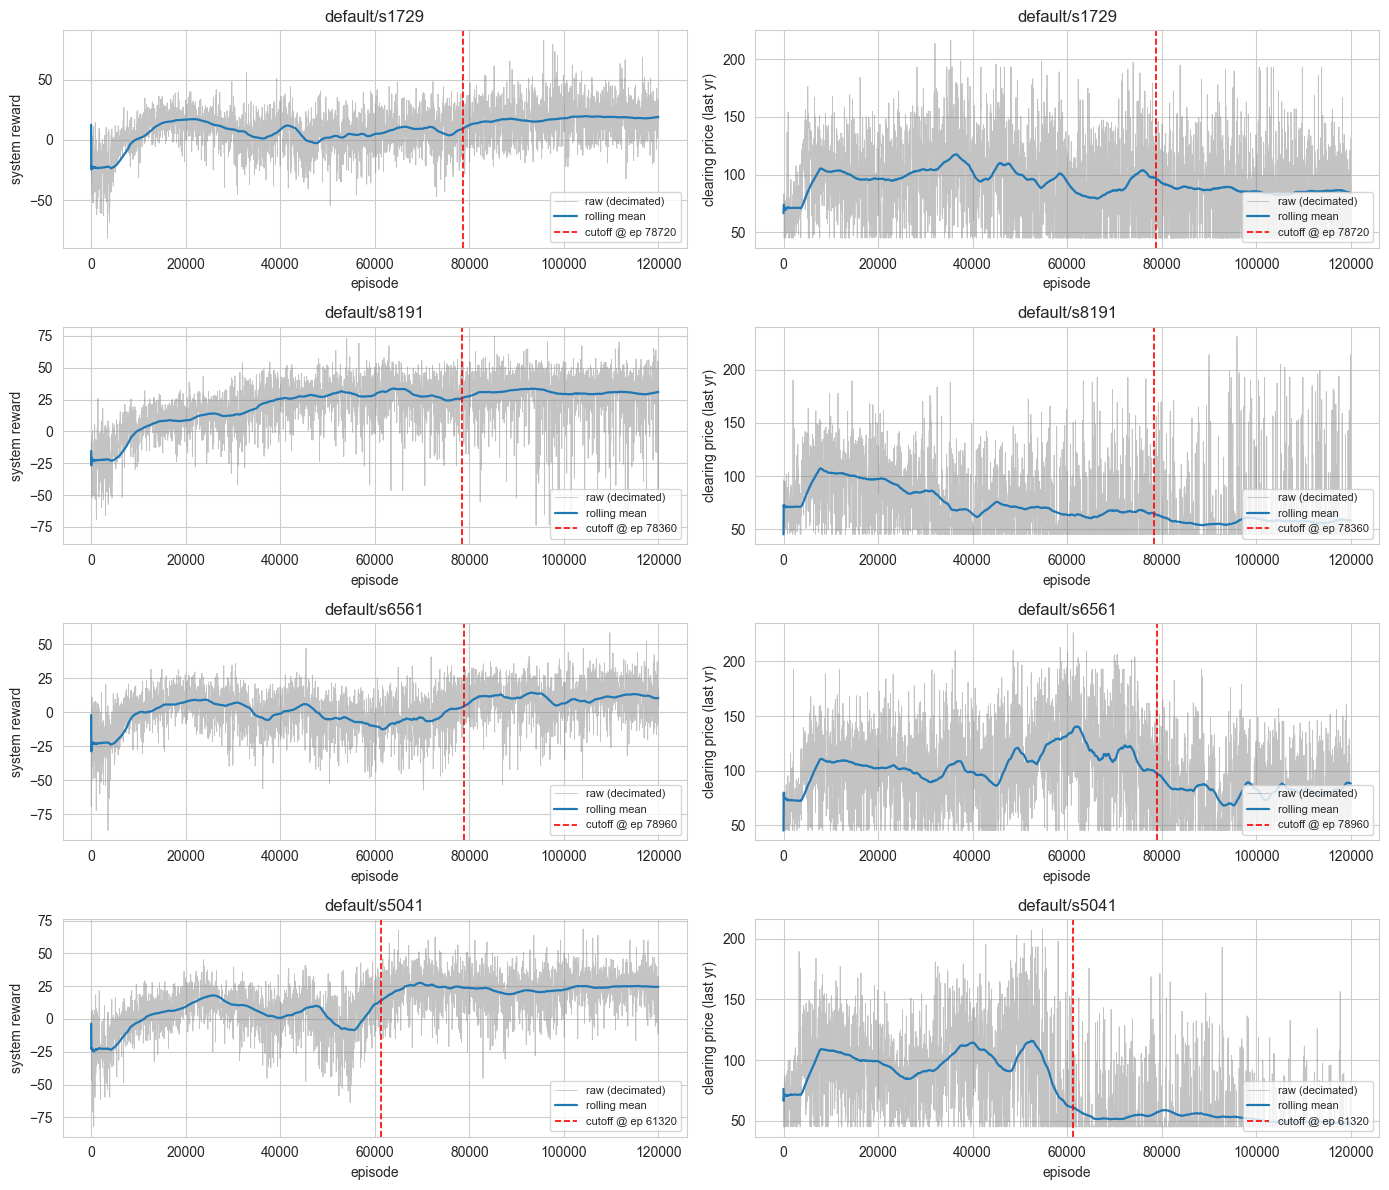

In [9]:
# Visualise reward and price trajectories with the agreed cutoff marked.
# The grey "raw" overlay is decimated to MAX_PLOT_POINTS so this is fast even
# for 100k+-episode runs; the rolling mean is computed on the full series.
n = len(runs)
fig, axes = plt.subplots(n, 2, figsize=(14, 3.0 * n), squeeze=False)
for row_idx, (k, run) in enumerate(runs.items()):
    rew = _system_reward_series(run['ep_df'])
    px  = run['ep_df'].get('clearing_price_last', pd.Series([])).values
    cutoff = conv_starts[k]
    for ax, y, ylabel in [(axes[row_idx, 0], rew, 'system reward'),
                          (axes[row_idx, 1], px,  'clearing price (last yr)')]:
        if len(y) == 0:
            ax.set_axis_off(); continue
        y_dec, x_dec = decimate_series(y, MAX_PLOT_POINTS)
        ax.plot(x_dec, y_dec, lw=0.6, alpha=0.5, color='#888', label='raw (decimated)')
        smooth = pd.Series(y).rolling(max(5, len(y) // 30), min_periods=1).mean()
        sm_dec, sx_dec = decimate_series(smooth.values, MAX_PLOT_POINTS)
        ax.plot(sx_dec, sm_dec, lw=1.6, color='C0', label='rolling mean')
        ax.axvline(cutoff, color='red', ls='--', lw=1.2, label=f'cutoff @ ep {cutoff}')
        ax.set(xlabel='episode', ylabel=ylabel, title=f'{k[1]}/s{k[2]}')
        ax.legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()


**Interpretation.** The two detectors should *broadly* agree on
where the trajectory levels off; we take the later of the two as the
conservative cutoff. With a 100-episode smoke run the detectors are
noisy by construction (insufficient samples for a stable rolling mean
or PELT prior), so the cutoff lands near the run end — that is
expected. On the production-scale sweep these cutoffs typically settle
around 60–80 % of `n_episodes`.

---

## §C2 — Cross-Seed Reproducibility (claim RQ1.b)

> Seed-bin fan charts on six headline metrics + a converged-window CV
> table. If converged-window CV is small relative to expected
> cross-variant differences, RQ2 / RQ3 claims are well-supported.

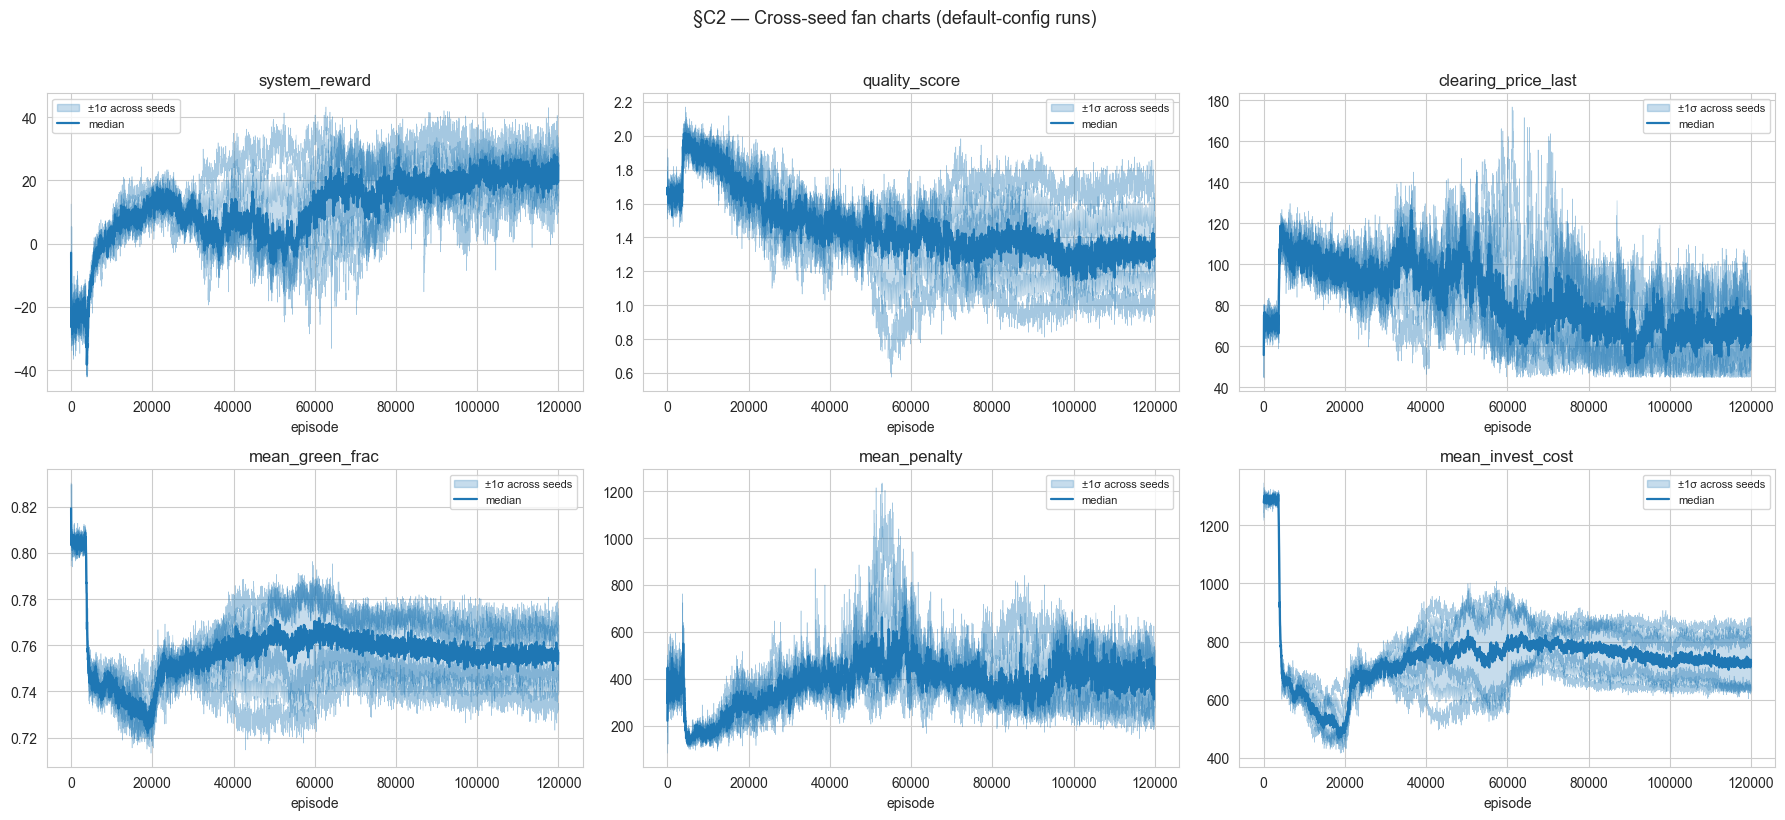

In [10]:
def _system_metric(df, agg, prefix=None, col=None):
    if prefix is not None:
        cols = agent_cols(df, prefix)
        if not cols: return pd.Series(dtype=float)
        x = df[cols]
        return x.sum(axis=1) if agg == 'sum' else x.mean(axis=1)
    if col is not None and col in df.columns:
        return df[col]
    return pd.Series(dtype=float)


HEADLINE = [
    ('system_reward',        lambda r: _system_metric(r['ep_df'], 'sum',  prefix='reward')),
    ('quality_score',        lambda r: _system_metric(r['ep_df'], 'sum',  col='quality_score')),
    ('clearing_price_last',  lambda r: _system_metric(r['ep_df'], 'sum',  col='clearing_price_last')),
    ('mean_green_frac',      lambda r: _system_metric(r['ep_df'], 'mean', prefix='green_frac')),
    ('mean_penalty',         lambda r: _system_metric(r['ep_df'], 'mean', prefix='penalty')),
    ('mean_invest_cost',     lambda r: _system_metric(r['ep_df'], 'mean', prefix='invest_cost')),
]

# Operate within the default-only runs; cross-variant fan charts belong
# in R1, not the credibility section.
default_keys = list(DEFAULT_RUNS)

def _fan_panel(ax, name, fn, smoothing=20, max_pts=MAX_PLOT_POINTS):
    series = []
    for k in default_keys:
        s = fn(DEFAULT_RUNS[k])
        if s.empty: continue
        series.append(s.rolling(smoothing, min_periods=1).mean().values)
    if not series:
        ax.set_axis_off(); return
    L = min(len(s) for s in series)
    arr = np.stack([s[:L] for s in series])
    # Decimate the per-seed arrays for plotting; keep the shared x-axis aligned
    # (uniform stride, identical across series).
    if L > max_pts:
        step = max(1, L // max_pts)
        x = np.arange(0, L, step)
        arr = arr[:, ::step]
    else:
        x = np.arange(L)
    med = np.median(arr, axis=0)
    lo, hi = np.percentile(arr, [16, 84], axis=0)
    ax.fill_between(x, lo, hi, alpha=0.25, color='C0', label='±1σ across seeds')
    ax.plot(x, med, color='C0', lw=1.6, label='median')
    for s in arr:
        ax.plot(x, s, color='C0', lw=0.4, alpha=0.4)
    ax.set(title=name, xlabel='episode')
    ax.legend(fontsize=8)


fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, (name, fn) in zip(axes.flat, HEADLINE):
    _fan_panel(ax, name, fn)
plt.suptitle('§C2 — Cross-seed fan charts (default-config runs)', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()


In [11]:
# Converged-window CV table.
rows = []
for name, fn in HEADLINE:
    vals = []
    for k in default_keys:
        s = fn(DEFAULT_RUNS[k])
        if s.empty: continue
        ep = DEFAULT_RUNS[k]['ep_df']
        cut = conv_starts.get(k, int(0.8 * len(ep)))
        seg = s.iloc[cut:]
        if len(seg) > 0:
            vals.append(float(seg.mean()))
    if not vals: continue
    arr = np.array(vals)
    mu = float(arr.mean()); sd = float(arr.std(ddof=1)) if len(arr) > 1 else float('nan')
    rows.append({'metric': name, 'n_seeds': len(arr),
                 'mean across seeds': mu, 'std across seeds': sd,
                 'cv (%)': 100.0 * sd / abs(mu) if mu else float('nan')})
cv_df = pd.DataFrame(rows)
display(cv_df.style.format({'mean across seeds': '{:.4g}', 'std across seeds': '{:.3g}', 'cv (%)': '{:.2f}'}))

,metric,n_seeds,mean across seeds,std across seeds,cv (%)
0,system_reward,4,20.69,8.52,41.18
1,quality_score,4,1.346,0.279,20.70
2,clearing_price_last,4,69.07,17,24.63
3,mean_green_frac,4,0.7563,0.0156,2.06
4,mean_penalty,4,403.6,123,30.45
5,mean_invest_cost,4,751.9,97.7,12.99


**Interpretation.** On the production sweep we want headline `cv (%)`
below ~10 %. On the smoke dataset (only 2 seeds × 100 episodes) the CVs
are large and uninterpretable — the table is shown as a sanity check
that the pipeline runs, not as evidence.

---

## §S1 — Strategy Archetypes in the Converged Market (claim RQ3.a)

Per-(run, agent) feature vector built from the converged window. We
cluster with KMeans (k chosen by **Silhouette + Elbow**), confirm with
hierarchical clustering (Ward linkage, dendrogram), visualise in 2D via
PCA, and cross-tabulate the emergent clusters against the **designed**
archetype × reward-weighting cells. The clustering pipeline produced
here is reused by §S2 (variant comparison) and §R1 (regulatory shifts).

In [13]:
# --- Per-(run, agent) feature matrix --------------------------------
EPISODE_FEATURES = ['bid_price', 'avg_bid_mult', 'inv_onshore_share',
                    'inv_offshore_share', 'inv_solar_share', 'green_frac',
                    'invest_cost', 'penalty',
                    # v8.6.1 episode-level credit/debt aggregates
                    # (silently NaN-filled on older logs that lack them).
                    'peak_loan_outstanding', 'peak_carry_forward',
                    'final_treasury_reserve']
YEAR_FEATURES    = ['sec_buy_vol', 'sec_sell_vol',
                    # v8.6.1 year-level compliance/credit features
                    'coverage_gap', 'effective_penalty_rate',
                    'carry_forward_end', 'treasury_reserve',
                    'loan_outstanding']
UDBC_BUCKETS     = ['U', 'D', 'M', 'B', 'C']


def build_strategy_features(run_subset, conv_starts):
    rows = []
    for k, run in run_subset.items():
        ep = run['ep_df']
        yr = run['yr_df']
        cut = conv_starts.get(k, int(0.8 * len(ep)))
        ep_c = ep.iloc[cut:]
        yr_c = yr[yr['episode'] >= cut] if 'episode' in yr.columns else yr
        cfg = run['config']
        for i in range(N_AGENTS):
            row = {'sweep': k[0], 'variant': k[1], 'seed': k[2],
                   'agent': i + 1,
                   'archetype': archetype_of(i, cfg),
                   'weighting': weighting_of(i, cfg)}
            for prefix in EPISODE_FEATURES:
                col = f'{prefix}_A{i+1}'
                row[prefix] = float(ep_c[col].mean()) if col in ep_c.columns else np.nan
            for prefix in YEAR_FEATURES:
                col = f'{prefix}_A{i+1}'
                row[prefix] = float(yr_c[col].mean()) if col in yr_c.columns else np.nan
            udbc_total = 0.0; udbc_vec = {}
            for b in UDBC_BUCKETS:
                col = f'udbc_{b}_total_A{i+1}'
                v = float(ep_c[col].mean()) if col in ep_c.columns else 0.0
                udbc_vec[b] = v; udbc_total += v
            for b in UDBC_BUCKETS:
                row[f'udbc_{b}_share'] = (udbc_vec[b] / udbc_total) if udbc_total > 1e-9 else 0.0
            rows.append(row)
    return pd.DataFrame(rows)


def feature_columns(df):
    base = list(EPISODE_FEATURES) + list(YEAR_FEATURES) + [f'udbc_{b}_share' for b in UDBC_BUCKETS]
    return [c for c in base if c in df.columns]


feat_df = build_strategy_features(DEFAULT_RUNS, conv_starts)
print(f'Per-(run, agent) feature matrix: {feat_df.shape[0]} rows × {feat_df.shape[1]} cols')
display(feat_df.head())

MemoryError: Unable to allocate 782. MiB for an array with shape (414, 495360) and data type float32

In [ ]:
# --- Standardise + KMeans with Silhouette/Elbow ---------------------
def _prepare_X(df):
    feats = feature_columns(df)
    X = df[feats].values.astype(float)
    # Drop columns that are entirely NaN or zero-variance.
    keep = []
    for j, name in enumerate(feats):
        col = X[:, j]
        col = col[np.isfinite(col)]
        if len(col) > 0 and np.nanstd(col) > 1e-12:
            keep.append(j)
    feats = [feats[j] for j in keep]
    X = X[:, keep]
    # Replace NaN with column means before scaling.
    col_means = np.nanmean(X, axis=0)
    nan_mask = ~np.isfinite(X)
    X[nan_mask] = np.take(col_means, np.where(nan_mask)[1])
    scaler = StandardScaler().fit(X)
    return scaler.transform(X), feats, scaler


X, feats, scaler = _prepare_X(feat_df)
print('Feature columns kept after variance filter:', feats)
print('X shape:', X.shape)

K_RANGE = range(2, min(8, len(X)))
sil_scores, inertias = [], []
for k in K_RANGE:
    if k >= len(X):
        sil_scores.append(np.nan); inertias.append(np.nan); continue
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    inertias.append(km.inertia_)
    try:
        sil_scores.append(silhouette_score(X, km.labels_))
    except Exception:
        sil_scores.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, 'o-')
axes[0].set(title='Elbow — KMeans inertia', xlabel='k', ylabel='inertia')
axes[1].plot(list(K_RANGE), sil_scores, 'o-', color='C2')
axes[1].set(title='Silhouette — KMeans', xlabel='k', ylabel='silhouette')
plt.tight_layout(); plt.show()

valid = [(k, s) for k, s in zip(K_RANGE, sil_scores) if np.isfinite(s)]
K_BEST = max(valid, key=lambda kv: kv[1])[0] if valid else 3
print(f'Selected k = {K_BEST} (max silhouette).')

In [ ]:
# --- Final KMeans + hierarchical confirmation -----------------------
km = KMeans(n_clusters=K_BEST, n_init=20, random_state=0).fit(X)
feat_df = feat_df.copy()
feat_df['kmeans_cluster'] = km.labels_

# Hierarchical (Ward) — confirms cluster count via dendrogram.
Z = linkage(X, method='ward')
hier_labels = fcluster(Z, t=K_BEST, criterion='maxclust')
feat_df['hier_cluster'] = hier_labels

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
labels = [f"{r['variant'][:6]}/s{r['seed']}/A{r['agent']}" for _, r in feat_df.iterrows()]
dendrogram(Z, labels=labels, leaf_rotation=90, ax=axes[0])
axes[0].set(title=f'Hierarchical clustering (Ward) — cut at k={K_BEST}')
axes[0].tick_params(axis='x', labelsize=7)

# PCA scatter coloured by KMeans cluster.
pca = PCA(n_components=2, random_state=0).fit(X)
P = pca.transform(X)
ax = axes[1]
for c in range(K_BEST):
    sel = km.labels_ == c
    ax.scatter(P[sel, 0], P[sel, 1], label=f'cluster {c}', s=60, alpha=0.85)
ax.set(title=f'PCA projection — KMeans clusters (var explained: {pca.explained_variance_ratio_.sum():.2%})',
       xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
# --- Cross-tabulate emergent cluster vs designed archetype × weighting
ct = pd.crosstab(
    [feat_df['archetype'], feat_df['weighting']],
    feat_df['kmeans_cluster'],
    margins=True,
)
print('Designed archetype × weighting  vs  KMeans cluster:')
display(ct)

# Same for hierarchical for the multi-method robustness story.
ct_h = pd.crosstab(
    [feat_df['archetype'], feat_df['weighting']],
    feat_df['hier_cluster'],
    margins=True,
)
print('Designed archetype × weighting  vs  Hierarchical cluster:')
display(ct_h)

**Interpretation.** A diagonal-ish cross-tab indicates the
emergent clustering recovers the designed archetypes. Off-diagonal mass
is itself a finding (e.g. archetype heterogeneity collapsing under a
specific reward weighting, or two archetypes converging onto the same
strategy). The hierarchical and KMeans tables should agree on the
qualitative grouping — when they don't, the strategy space is
ambiguous and the headline claim needs hedging.

In [ ]:
# Persist the fitted feature space so §S2 and §R1 can project new
# (variant, seed, agent) feature vectors into the *same* space.
S1_ARTIFACTS = dict(scaler=scaler, pca=pca, kmeans=km, feature_cols=feats, k=K_BEST)
print('Stored S1 artefacts: scaler, PCA, KMeans, feature_cols.')

---

## §S4 — Strategy-Feature Correlation Heatmap

Per-(run, agent) feature correlations across the same matrix used in §S1.
Useful for the thesis interpretation pass: tells us which strategy axes are
near-collinear (so a single PC explains most of the relevant variance) and
which are independent.


In [ ]:
# Pearson correlation across §S1 features (rows: per-(run, agent) cells).
# Cheap to recompute; safe to re-run if you reload `feat_df`.
_corr_feats = feature_columns(feat_df)
if _corr_feats and len(feat_df) >= 4:
    C = feat_df[_corr_feats].corr()
    fig, ax = plt.subplots(figsize=(min(14, 0.45 * len(_corr_feats) + 4),
                                    min(12, 0.45 * len(_corr_feats) + 3)))
    sns.heatmap(C, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
                square=True, cbar_kws={'shrink': 0.7}, ax=ax,
                annot_kws={'size': 7})
    ax.set_title('§S4 — Pearson correlation of strategy features (per-(run,agent) cells)')
    plt.tight_layout(); plt.show()
    # Highlight the strongly collinear pairs (|r| ≥ 0.9, off-diagonal).
    pairs = []
    for i, a in enumerate(_corr_feats):
        for j, b in enumerate(_corr_feats):
            if j <= i: continue
            r = float(C.iloc[i, j])
            if abs(r) >= 0.9:
                pairs.append({'feature_a': a, 'feature_b': b, 'pearson_r': round(r, 3)})
    if pairs:
        print('Near-collinear feature pairs (|r| ≥ 0.9):')
        display(pd.DataFrame(pairs).sort_values('pearson_r', key=abs, ascending=False))
    else:
        print('No feature pairs with |r| ≥ 0.9 — features are reasonably independent.')
else:
    print('§S4 skipped — feature matrix too small or empty.')


---

## §S2 — How Reward Weights Shape Strategy (claim RQ3.b)

This is the headline RQ3 analysis. We use **two complementary contrasts**:

1. **Within the default config:** every default run already mixes
   pure-financial agents (`reward_weights=[1,0]`) with balanced-ESG
   agents (`reward_weights=[0.5,0.5]`). We project them into the §S1
   PCA space and compare centroid positions and within-group spread.
2. **Cross-variant (when available):** if the loaded sweeps include an
   `all_financial`-style variant (every learning agent with
   `[w_cost=1, w_green=0]`), we re-run the §S1 clustering on that
   variant's per-agent feature matrix and compare cluster count, spread
   in the §S1 PCA basis, and silhouette score against the default.

In [ ]:
# --- (1) Within-default contrast ------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for w, color in [('pure_financial', 'C3'), ('balanced_esg', 'C2')]:
    sel = feat_df['weighting'] == w
    if sel.sum():
        ax.scatter(P[sel, 0], P[sel, 1], label=w, color=color, s=70, alpha=0.85, edgecolor='k', linewidth=0.4)
        cx, cy = P[sel, 0].mean(), P[sel, 1].mean()
        ax.scatter([cx], [cy], marker='X', s=260, color=color, edgecolor='black', linewidth=1.5,
                   label=f'{w} centroid')
ax.set(title='Within-default — pure-financial vs balanced-ESG agents in §S1 PCA',
       xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(fontsize=8)

# Per-weighting feature means (standardised) — what differentiates the two?
ax = axes[1]
mu = feat_df.groupby('weighting')[feats].mean()
mu_std = (mu - mu.mean()) / (mu.std(ddof=0) + 1e-9)
mu_std.T.plot(kind='bar', ax=ax, color=['C2', 'C3'])
ax.axhline(0, color='k', lw=0.5)
ax.set(title='Standardised feature means by weighting',
       ylabel='z-score (across weighting groups)', xlabel='')
ax.legend(title='weighting')
plt.tight_layout(); plt.show()

In [ ]:
# --- (2) Cross-variant contrast (skip gracefully if unavailable) ----
# RQ3.b is sharpest on two thesis-sweep variants:
#   * all_fin  — every learning agent reward = [1.0, 0.0]; ESG removed entirely
#   * balanced — every agent has identical mix/budget/capex; only reward
#                weighting differs (cleanest possible test, no endowment
#                confound)
# Either may be missing on partial loads; we render whichever is present and
# keep the within-default contrast above as the lower-bar evidence.
def _matches(variant, *needles):
    return any(n in variant for n in needles)

af_keys  = [k for k, v in OVERRIDE_RUNS.items()
            if _matches(v['variant'], 'all_fin', 'all_financial')]
bal_keys = [k for k, v in OVERRIDE_RUNS.items()
            if _matches(v['variant'], 'balanced')]


def _project_into_default_basis(run_subset):
    """Build features → impute NaNs with default-fitted column means → scale →
    project into the default-fitted PCA basis. Returns (P, X_std, n)."""
    feat = build_strategy_features(run_subset, conv_starts)
    if feat.empty:
        return np.empty((0, 2)), np.empty((0, len(feats))), 0
    Xv = feat[feats].values.astype(float)
    col_means = np.nanmean(Xv, axis=0)
    nan_mask = ~np.isfinite(Xv)
    Xv[nan_mask] = np.take(col_means, np.where(nan_mask)[1])
    Xv_std = scaler.transform(Xv)
    return pca.transform(Xv_std), Xv_std, len(Xv)


def _silhouette_sweep(X_std, k_max=8):
    """Independent KMeans across k=2..k_max with silhouette scoring."""
    if len(X_std) < 4:
        return [], None, None
    rng = range(2, min(k_max, len(X_std)))
    sils = []
    for k in rng:
        if k >= len(X_std):
            sils.append(np.nan); continue
        km_ = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_std)
        try:
            sils.append(silhouette_score(X_std, km_.labels_))
        except Exception:
            sils.append(np.nan)
    valid = [(k, s) for k, s in zip(rng, sils) if np.isfinite(s)]
    if not valid:
        return sils, None, None
    k_best = max(valid, key=lambda kv: kv[1])[0]
    km_final = KMeans(n_clusters=k_best, n_init=20, random_state=0).fit(X_std)
    return sils, k_best, km_final


def _spread(P_):
    return float(np.mean(np.linalg.norm(P_ - P_.mean(axis=0), axis=1))) if len(P_) else float('nan')


# Default-only summary row (always rendered as the reference).
summary_rows = [{'variant': 'default', 'n': len(P),
                 'silhouette': max(sil_scores) if sil_scores else np.nan,
                 'k_best': K_BEST, 'mean radius (PC1-PC2)': _spread(P)}]

panels = [('default', P, km.labels_, f'default — KMeans (k={K_BEST})')]

for label, key_list in [('all_financial', af_keys), ('balanced', bal_keys)]:
    if not key_list:
        print(f'§S2 — {label} variant not loaded — panel skipped.')
        continue
    sub = {k: OVERRIDE_RUNS[k] for k in key_list}
    Pv, Xv_std, nv = _project_into_default_basis(sub)
    sils_v, k_v, km_v = _silhouette_sweep(Xv_std)
    panels.append((label, Pv,
                   km_v.labels_ if km_v is not None else np.zeros(nv, dtype=int),
                   f'{label} — KMeans (k={k_v})' if k_v else f'{label} (n={nv})'))
    summary_rows.append({
        'variant': label, 'n': nv,
        'silhouette': max(sils_v) if sils_v else np.nan,
        'k_best': k_v, 'mean radius (PC1-PC2)': _spread(Pv),
    })

# Render the available panels side-by-side in the same PCA projection.
n_panels = len(panels)
fig, axes = plt.subplots(1, n_panels, figsize=(5.0 * n_panels, 4.5),
                         sharex=True, sharey=True, squeeze=False)
for ax, (title_lab, points, lbls, title) in zip(axes[0], panels):
    if len(points) == 0:
        ax.set_axis_off(); continue
    for c in np.unique(lbls):
        sel = lbls == c
        ax.scatter(points[sel, 0], points[sel, 1], s=60, alpha=0.85, label=f'cluster {c}')
    ax.scatter(points[:, 0].mean(), points[:, 1].mean(), marker='X', s=240,
               color='k', edgecolor='white', linewidth=1.5, label=f'{title_lab} centroid')
    ax.set(title=title, xlabel='PC1', ylabel='PC2')
    ax.legend(fontsize=7)
plt.suptitle('§S2 — Strategy space across reward-weight variants (§S1 PCA basis)', y=1.02)
plt.tight_layout(); plt.show()

display(pd.DataFrame(summary_rows))
print('Headline RQ3.b read: lower silhouette / smaller PC-radius in `all_financial`'
      ' (or `balanced` with all financial agents) versus `default` is evidence that'
      ' the ESG component drives strategic heterogeneity.')

# Outcome comparison: when ESG is removed, do aggregate green outcomes also flatten?
def _green_means(run_subset):
    rows = []
    for k, run in run_subset.items():
        ep = run['ep_df']; cut = conv_starts.get(k, int(0.8 * len(ep)))
        ep_c = ep.iloc[cut:]
        if ep_c.empty: continue
        gf = float(_system_metric(ep_c, 'mean', prefix='green_frac').mean())
        pn = float(_system_metric(ep_c, 'mean', prefix='penalty').mean())
        cp = float(ep_c['clearing_price_last'].mean()) if 'clearing_price_last' in ep_c.columns else np.nan
        rows.append({'variant': k[1], 'seed': k[2], 'green_frac': gf, 'penalty': pn, 'clearing_price': cp})
    return pd.DataFrame(rows)


outcomes = []
outcomes.append(_green_means(DEFAULT_RUNS).assign(group='default'))
if af_keys:  outcomes.append(_green_means({k: OVERRIDE_RUNS[k] for k in af_keys}).assign(group='all_financial'))
if bal_keys: outcomes.append(_green_means({k: OVERRIDE_RUNS[k] for k in bal_keys}).assign(group='balanced'))
if len(outcomes) > 1:
    out_cmp = (pd.concat(outcomes, ignore_index=True)
                  .groupby('group')[['green_frac', 'penalty', 'clearing_price']]
                  .agg(['mean', 'std', 'count']))
    print('Outcome comparison across reward-weighting variants:')
    display(out_cmp)


**Interpretation.** The within-default contrast is the lower-bar
evidence: even *inside* the same training run, balanced-ESG agents
should sit further along whichever PC tracks green investment than
their pure-financial twins. The cross-variant comparison is the
stronger test: if the all-financial variant collapses to fewer
clusters and a tighter PCA cloud, removing the ESG component is
*causing* strategic homogenisation. If the spread does **not**
collapse, agents found other reasons to differentiate (cost-structure
heterogeneity, urgency scalars, etc.) — a finding worth reporting
honestly.

---

## §S3 — Are Strategies Economically Rational? (claim RQ3.c, Tier 2)

Three sub-analyses:

* **H1.** *Carbon price drives green investment.* Per-(run, agent, year):
  label = 1 if `invest_cost > threshold`. Features = lag-1 clearing price,
  archetype dummies, agent bank at start of year, year. Logistic
  regression with **L1/LASSO** (Lecture 4 + 8) and a **Random Forest**
  for the partial-dependence cross-check on the lagged carbon price.
* **H2.** *High-fossil agents transition faster.* Label = 1 if the
  agent's `delta_green` over the episode exceeds the median. Features =
  initial mix, archetype dummies, mean clearing price seen by the
  agent. Same LASSO + RF setup.
* **Anchor check.** Realised mean clearing price per year (across runs)
  vs `compute_fundamental_anchor(year, config)`. One overlay plot,
  Pearson correlation, and mean absolute deviation.

In [ ]:
# --- (a) Anchor-vs-realised credibility plot -------------------------
def _per_year_clearing(run):
    yr = run['yr_df']
    if yr.empty or 'year' not in yr.columns: return None
    cut = conv_starts.get(run_key(run), int(0.8 * len(run['ep_df'])))
    yrc = yr[yr['episode'] >= cut] if 'episode' in yr.columns else yr
    return yrc.groupby('year')['clearing_price'].mean()


anchor_rows = []
for k, run in DEFAULT_RUNS.items():
    cp = _per_year_clearing(run)
    if cp is None: continue
    for y in range(N_YEARS):
        anchor_rows.append({
            'sweep': k[0], 'variant': k[1], 'seed': k[2],
            'year': y,
            'clearing': float(cp.get(y, np.nan)),
            'anchor':   compute_fundamental_anchor(y, run['config']),
        })
anchor_df = pd.DataFrame(anchor_rows)
panel = anchor_df.groupby('year').agg(realised_mean=('clearing', 'mean'),
                                      realised_std =('clearing', 'std'),
                                      anchor=('anchor', 'mean')).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(panel['year'], panel['anchor'],        '-o',  color='black',      lw=2,   label='fundamental anchor')
ax.plot(panel['year'], panel['realised_mean'], '-s',  color='C0',         lw=2,   label='realised mean (across seeds)')
ax.fill_between(panel['year'],
                panel['realised_mean'] - panel['realised_std'].fillna(0),
                panel['realised_mean'] + panel['realised_std'].fillna(0),
                alpha=0.20, color='C0', label='±1σ across seeds')
ax.set(xlabel='year', ylabel='EUR / tCO₂', title='§S3 anchor check — realised clearing vs fundamental anchor')
ax.legend()
plt.tight_layout(); plt.show()

valid = panel.dropna(subset=['realised_mean', 'anchor'])
if len(valid) > 1:
    corr = float(np.corrcoef(valid['realised_mean'], valid['anchor'])[0, 1])
    mad  = float(np.mean(np.abs(valid['realised_mean'] - valid['anchor'])))
    print(f'Pearson correlation (realised, anchor): {corr:+.3f}')
    print(f'Mean absolute deviation: {mad:.2f} EUR/t')
else:
    print('Not enough year-level data points to compute correlation.')

In [ ]:
# --- (b) Hypothesis test datasets ------------------------------------
# Vectorised per-(run, agent, year) panel: groupby('year').mean() once per run
# instead of N_AGENTS × N_YEARS boolean filters. On a 1.4M-row year_log this
# is two orders of magnitude faster than the per-cell loop.
def _per_agent_year_table(runs_dict):
    pieces = []
    for k, run in tqdm(runs_dict.items(), desc='§S3 panel', unit='run', leave=False):
        yr = run['yr_df']
        cfg = run['config']
        if yr.empty or 'year' not in yr.columns:
            continue
        cut = conv_starts.get(k, int(0.8 * len(run['ep_df'])))
        yrc = yr[yr['episode'] >= cut] if 'episode' in yr.columns else yr
        if yrc.empty:
            continue
        # Year-mean of every numeric column in one pass.
        ymean = yrc.groupby('year').mean(numeric_only=True)
        cp_year = ymean['clearing_price'] if 'clearing_price' in ymean.columns else pd.Series(dtype=float)
        for i in range(N_AGENTS):
            inv_col  = f'invest_cost_A{i+1}'
            bank_col = f'bank_start_A{i+1}'
            if inv_col not in ymean.columns:
                continue
            mix = cfg['companies']['initial_mix'][i]
            df_i = pd.DataFrame({
                'year':       ymean.index.astype(int),
                'invest_cost': ymean[inv_col].values,
                'bank_start':  ymean[bank_col].values if bank_col in ymean.columns else np.nan,
                'clearing_price':     ymean['clearing_price'].values if 'clearing_price' in ymean.columns else np.nan,
            })
            df_i['lag_clearing_price'] = df_i['clearing_price'].shift(1)
            df_i['variant']   = k[1]
            df_i['seed']      = k[2]
            df_i['agent']     = i + 1
            df_i['archetype'] = archetype_of(i, cfg)
            df_i['weighting'] = weighting_of(i, cfg)
            for j, t in enumerate(['coal', 'gas', 'onshore', 'offshore', 'solar']):
                df_i[f'init_{t}'] = float(mix[j])
            pieces.append(df_i)
    if not pieces:
        return pd.DataFrame()
    return pd.concat(pieces, ignore_index=True)


pay = _per_agent_year_table(DEFAULT_RUNS)
print(f'Per-(agent, year) panel: {len(pay)} rows')
display(pay.head())


In [ ]:
# --- (c) H1 — does carbon price drive green investment? -------------
INV_THRESH = float(np.nanpercentile(pay['invest_cost'], 75)) if len(pay) else 0.0
print(f'Invest threshold (top-quartile invest_cost): {INV_THRESH:.2f} M€')

H1 = pay.dropna(subset=['lag_clearing_price', 'bank_start']).copy()
H1['invests'] = (H1['invest_cost'] > INV_THRESH).astype(int)
arche_dummies = pd.get_dummies(H1['archetype'], prefix='arch', drop_first=True)
H1_X = pd.concat([H1[['lag_clearing_price', 'bank_start', 'year']], arche_dummies], axis=1)
H1_y = H1['invests']

if H1_y.nunique() < 2 or len(H1_y) < 30:
    print('H1 skipped — insufficient label variation or rows.')
else:
    pipe = Pipeline([
        ('scale', StandardScaler()),
        ('lr',    LogisticRegression(penalty='l1', solver='saga', max_iter=2000, C=0.5, random_state=0)),
    ])
    cv_score = cross_val_score(pipe, H1_X, H1_y, cv=StratifiedKFold(n_splits=min(5, H1_y.value_counts().min()), shuffle=True, random_state=0), scoring='roc_auc')
    pipe.fit(H1_X, H1_y)
    coefs = pd.Series(pipe.named_steps['lr'].coef_[0], index=H1_X.columns).sort_values(key=abs, ascending=False)
    print(f'H1 logistic LASSO  —  CV AUC = {cv_score.mean():.3f} ± {cv_score.std():.3f}')
    print('Coefficients (standardised features):')
    display(coefs.to_frame('coef'))

    # Random Forest + partial dependence on lagged clearing price.
    rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=0, n_jobs=-1).fit(H1_X, H1_y)
    fi = pd.Series(rf.feature_importances_, index=H1_X.columns).sort_values(ascending=False)
    print('Random forest feature importances:')
    display(fi.to_frame('importance'))

    pd_res = partial_dependence(rf, H1_X, ['lag_clearing_price'], grid_resolution=40)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(pd_res['grid_values'][0], pd_res['average'][0], lw=2)
    ax.axvline(50, color='red', ls='--', label='theory threshold ≈ 50 €/t')
    ax.set(xlabel='lag clearing price (EUR/t)', ylabel='P(invests | x)',
           title='H1 — RF partial dependence on lagged carbon price')
    ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
# --- (d) H2 — heterogeneity: high-fossil agents transition faster ----
agent_panel = (
    pay.groupby(['variant', 'seed', 'agent', 'archetype', 'weighting'])
       .agg(mean_clearing=('clearing_price', 'mean'),
            total_invest=('invest_cost', 'sum'),
            init_coal=('init_coal', 'first'),
            init_gas=('init_gas', 'first'),
            init_onshore=('init_onshore', 'first'),
            init_offshore=('init_offshore', 'first'),
            init_solar=('init_solar', 'first'))
       .reset_index()
)
if len(agent_panel) > 0 and 'total_invest' in agent_panel.columns:
    med = float(agent_panel['total_invest'].median())
    agent_panel['transitions'] = (agent_panel['total_invest'] > med).astype(int)
    arche_d = pd.get_dummies(agent_panel['archetype'], prefix='arch', drop_first=True)
    H2_X = pd.concat([agent_panel[['mean_clearing', 'init_coal', 'init_gas']], arche_d], axis=1)
    H2_y = agent_panel['transitions']
    if H2_y.nunique() < 2 or len(H2_y) < 8:
        print('H2 skipped — insufficient sample size for cross-validated logit.')
    else:
        pipe2 = Pipeline([('scale', StandardScaler()),
                          ('lr',    LogisticRegression(penalty='l1', solver='saga', max_iter=2000, C=0.5, random_state=0))])
        n_splits_h2 = max(2, min(5, int(H2_y.value_counts().min())))
        cv2 = cross_val_score(pipe2, H2_X, H2_y,
                              cv=StratifiedKFold(n_splits=n_splits_h2, shuffle=True, random_state=0),
                              scoring='roc_auc')
        pipe2.fit(H2_X, H2_y)
        coefs2 = pd.Series(pipe2.named_steps['lr'].coef_[0], index=H2_X.columns).sort_values(key=abs, ascending=False)
        print(f'H2 logistic LASSO — CV AUC = {cv2.mean():.3f} ± {cv2.std():.3f}')
        print('Sign of init_coal positive ⇒ higher-fossil agents transition faster (the theory prediction).')
        display(coefs2.to_frame('coef'))
else:
    print('H2 skipped — agent panel empty.')

**Interpretation.** A positive lag-clearing-price coefficient
in H1 plus a step-up in the RF partial dependence near the theoretical
50 €/t LCOE crossover supports the *carbon price drives green
investment* claim. A positive `init_coal` coefficient in H2 supports
the *high-fossil agents transition faster* claim. The anchor overlay
provides the credibility floor: if realised prices track the
fundamental, the simulation is producing economically-grounded prices,
which feeds RQ1 too.

---

## §R1 — Regulatory Shifts (claim RQ2.a)

> If the loaded sweeps include non-default variants (LRF / MSR / cap
> changes) we run §S1's clustering on each variant separately and
> project everything into the **default-fitted** §S1 PCA basis to make
> the visual comparison direct. Outcomes are summarised with cross-seed
> boxplots and IQR-based outlier flagging.

In [ ]:
variant_keys = sorted({(k[0], k[1]) for k in runs})
variant_keys_overrides = [(s, v) for (s, v) in variant_keys
                           if any(runs[k]['has_overrides'] for k in runs if k[0] == s and k[1] == v)]

if not variant_keys_overrides:
    print('No override variants loaded — §R1 cluster-shift comparison skipped.')
else:
    n_var = len(variant_keys)
    n_cols = min(n_var, 3); n_rows = int(np.ceil(n_var / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 5 * n_rows), squeeze=False)
    for ax_idx, (sw, vn) in enumerate(variant_keys):
        ax = axes[ax_idx // n_cols, ax_idx % n_cols]
        var_runs = {k: runs[k] for k in runs if k[0] == sw and k[1] == vn}
        v_feat = build_strategy_features(var_runs, conv_starts)
        if v_feat.empty:
            ax.set_axis_off(); continue
        v_X = v_feat[feats].values.astype(float)
        col_means = np.nanmean(v_X, axis=0)
        nan_mask = ~np.isfinite(v_X)
        v_X[nan_mask] = np.take(col_means, np.where(nan_mask)[1])
        v_P = pca.transform(scaler.transform(v_X))
        # Colour by KMeans cluster *as predicted by the default-fitted KMeans* —
        # this turns "where do this variant's agents land?" into "do they fall in
        # default-style clusters or do new clusters emerge?".
        labels_pred = km.predict(scaler.transform(v_X))
        for c in np.unique(labels_pred):
            sel = labels_pred == c
            ax.scatter(v_P[sel, 0], v_P[sel, 1], s=60, alpha=0.85, label=f'default-cluster {c}')
        ax.scatter(v_P[:, 0].mean(), v_P[:, 1].mean(), marker='X', s=260, color='k',
                   edgecolor='white', linewidth=1.5, label='variant centroid')
        ax.set(title=f'{vn}', xlabel='PC1', ylabel='PC2')
        ax.legend(fontsize=7)
    for ax_idx in range(len(variant_keys), n_rows * n_cols):
        axes[ax_idx // n_cols, ax_idx % n_cols].set_axis_off()
    plt.suptitle('§R1 — Strategy positions in §S1 PCA basis, by variant', y=1.02, fontsize=13)
    plt.tight_layout(); plt.show()

In [ ]:
# --- Outcome boxplots with IQR outlier flagging ---------------------
OUT_METRICS = [('mean_clearing_price', lambda r: float(r['yr_df']['clearing_price'].mean()) if 'clearing_price' in r['yr_df'].columns else np.nan),
               ('mean_green_frac',     lambda r: float(np.nanmean([r['ep_df'][f'green_frac_A{i+1}'].iloc[-50:].mean()
                                                                    for i in range(N_AGENTS) if f'green_frac_A{i+1}' in r['ep_df'].columns]))),
               ('total_penalty',       lambda r: float(np.nansum([r['ep_df'][f'penalty_A{i+1}'].iloc[-50:].mean()
                                                                   for i in range(N_AGENTS) if f'penalty_A{i+1}' in r['ep_df'].columns]))),
               ('quality_score',       lambda r: float(r['ep_df']['quality_score'].iloc[-50:].mean()) if 'quality_score' in r['ep_df'].columns else np.nan)]

rows = []
for k, run in runs.items():
    row = {'variant': k[1], 'seed': k[2]}
    for name, fn in OUT_METRICS:
        try: row[name] = fn(run)
        except Exception: row[name] = np.nan
    rows.append(row)
out_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, len(OUT_METRICS), figsize=(5 * len(OUT_METRICS), 4))
for ax, (name, _) in zip(axes, OUT_METRICS):
    sns.boxplot(data=out_df, x='variant', y=name, ax=ax, showfliers=False)
    sns.stripplot(data=out_df, x='variant', y=name, ax=ax, color='black', size=4, alpha=0.6)
    # IQR-based outlier flag for the within-variant distribution.
    for v in out_df['variant'].unique():
        sub = out_df[out_df['variant'] == v][name].dropna()
        if len(sub) >= 4:
            q1, q3 = sub.quantile([0.25, 0.75]); iqr = q3 - q1
            mask = (sub < q1 - 1.5 * iqr) | (sub > q3 + 1.5 * iqr)
            for v_idx, value in zip(sub.index[mask], sub[mask]):
                ax.annotate('!', xy=(list(out_df['variant'].unique()).index(v), value), color='red', fontsize=12, ha='center')
    ax.set_title(name); ax.tick_params(axis='x', rotation=20)
plt.suptitle('§R1 — Outcome distribution by variant (red ! = IQR outlier seed)', y=1.03)
plt.tight_layout(); plt.show()
display(out_df.groupby('variant').agg(['mean', 'std', 'count']))

---

### §R1.b — Cross-variant outcome statistics

For each loaded override variant we compute the per-seed mean of the
headline outcomes, the percentage change vs. the default-config mean, and
Cohen's *d* against the default seeds. With ~3 seeds per variant these are
descriptive (no formal hypothesis test) but they make the regulatory
channel explicit: which outcome moves the most under each variant?


In [ ]:
# Cross-variant outcome statistics. Rebuilt from `out_df` (cell §R1) so we
# stay consistent with the boxplot panel above.
if 'out_df' in dir() and not out_df.empty:
    metrics_present = [m for m in ['mean_clearing_price', 'mean_green_frac',
                                    'total_penalty', 'quality_score']
                        if m in out_df.columns]
    default_mask = out_df['variant'] == 'default'
    if not default_mask.any():
        print('§R1.b — `default` variant not loaded; skipping cross-variant stats.')
    else:
        ref = out_df[default_mask][metrics_present]
        ref_mu = ref.mean(); ref_sd = ref.std(ddof=1)

        rows = []
        for v in sorted(out_df['variant'].unique()):
            sub = out_df[out_df['variant'] == v][metrics_present]
            if sub.empty:
                continue
            for m in metrics_present:
                v_mu = float(sub[m].mean())
                v_sd = float(sub[m].std(ddof=1)) if len(sub) > 1 else float('nan')
                d_mu = float(ref_mu[m])
                # Pooled SD for Cohen's d (treat unequal sample sizes safely).
                pooled = float(np.sqrt(((len(sub) - 1) * (v_sd or 0) ** 2 +
                                        (len(ref) - 1) * (ref_sd[m] or 0) ** 2) /
                                       max(1, len(sub) + len(ref) - 2))) if len(ref) + len(sub) > 2 else float('nan')
                d_eff = (v_mu - d_mu) / pooled if (pooled and np.isfinite(pooled) and pooled > 1e-12) else float('nan')
                pct = 100.0 * (v_mu - d_mu) / d_mu if abs(d_mu) > 1e-9 else float('nan')
                rows.append({'variant': v, 'metric': m, 'n_seeds': int(len(sub)),
                             'mean': v_mu, 'std': v_sd, 'Δ vs default (%)': pct,
                             "Cohen's d": d_eff})
        rq2_stats = pd.DataFrame(rows)
        print('§R1.b — Per-variant outcome stats (vs. default reference):')
        display(rq2_stats.style.format({'mean': '{:.4g}', 'std': '{:.3g}',
                                        'Δ vs default (%)': '{:+.1f}',
                                        "Cohen's d": '{:+.2f}'}))

        # Identify the dominant regulatory channel per non-default variant.
        non_def = rq2_stats[rq2_stats['variant'] != 'default'].dropna(subset=["Cohen's d"])
        if not non_def.empty:
            dominant = (non_def.assign(_abs_d=non_def["Cohen's d"].abs())
                                .sort_values('_abs_d', ascending=False)
                                .groupby('variant')
                                .head(1)
                                .drop(columns='_abs_d'))
            print('§R1.b — Largest-effect channel per variant '
                  '(largest |Cohen\'s d| against default):')
            display(dominant.style.format({'mean': '{:.4g}', 'std': '{:.3g}',
                                            'Δ vs default (%)': '{:+.1f}',
                                            "Cohen's d": '{:+.2f}'}))
else:
    print('§R1.b skipped — outcome frame `out_df` not built.')


---

### §R1.c — Inflation-stress anchor check (`high_inf` variant)

The thesis sweep includes a single-seed `high_inf` cell with elevated
penalty inflation drift (4 % vs. 2 % default) and ~1.5× the inflation
variance. Two design components are sensitive to inflation:

* The **inflation-aware MA3 budget gate** uses `MA3 × infl(t)/infl(t-1)`
  so the price floor adapts to drift; a runaway clearing price under
  high inflation would mean the gate is failing.
* The **real-anchor ESG flow term** uses `anchor_real_t / anchor_real_0`,
  i.e. drift is divided out by construction.

We re-run §S3's anchor-credibility check restricted to `high_inf` and
report the same correlation / MAD numbers as a stress sanity check.


In [ ]:
# Re-use §S3's `_per_year_clearing` if it has been defined, otherwise build
# it inline. Keeps this cell runnable in any execution order.
inf_keys = [k for k, v in runs.items() if 'high_inf' in v['variant']]
if not inf_keys:
    print('§R1.c — `high_inf` variant not loaded; inflation-stress check skipped.')
else:
    rows = []
    for k in inf_keys:
        run = runs[k]; yr = run['yr_df']
        if yr.empty or 'year' not in yr.columns:
            continue
        cut = conv_starts.get(k, int(0.8 * len(run['ep_df'])))
        yrc = yr[yr['episode'] >= cut] if 'episode' in yr.columns else yr
        cp_year = yrc.groupby('year')['clearing_price'].mean()
        for y in range(N_YEARS):
            rows.append({'sweep': k[0], 'variant': k[1], 'seed': k[2],
                         'year': y,
                         'clearing': float(cp_year.get(y, np.nan)),
                         'anchor':   compute_fundamental_anchor(y, run['config'])})
    inf_df = pd.DataFrame(rows)
    if inf_df.empty or inf_df['clearing'].dropna().empty:
        print('§R1.c — high_inf rows lack clearing-price data — skipping.')
    else:
        panel_inf = (inf_df.groupby('year')
                            .agg(realised_mean=('clearing', 'mean'),
                                 realised_std =('clearing', 'std'),
                                 anchor=('anchor', 'mean'))
                            .reset_index())
        fig, ax = plt.subplots(figsize=(10, 4.5))
        ax.plot(panel_inf['year'], panel_inf['anchor'],        '-o', color='black', lw=2, label='fundamental anchor')
        ax.plot(panel_inf['year'], panel_inf['realised_mean'], '-s', color='C3',    lw=2, label='realised mean (high_inf seeds)')
        ax.fill_between(panel_inf['year'],
                        panel_inf['realised_mean'] - panel_inf['realised_std'].fillna(0),
                        panel_inf['realised_mean'] + panel_inf['realised_std'].fillna(0),
                        alpha=0.20, color='C3', label='±1σ across seeds')
        ax.set(xlabel='year', ylabel='EUR / tCO₂',
               title='§R1.c — high_inf: realised clearing vs fundamental anchor')
        ax.legend(); plt.tight_layout(); plt.show()

        valid = panel_inf.dropna(subset=['realised_mean', 'anchor'])
        if len(valid) > 1:
            corr = float(np.corrcoef(valid['realised_mean'], valid['anchor'])[0, 1])
            mad  = float(np.mean(np.abs(valid['realised_mean'] - valid['anchor'])))
            print(f'high_inf — Pearson correlation (realised, anchor): {corr:+.3f}')
            print(f'high_inf — Mean absolute deviation: {mad:.2f} EUR/t')
            print('Read: tracking should be comparable to the default-config anchor check '
                  'because the anchor is computed in real EUR by construction. '
                  'A large gap indicates the inflation-aware budget gate is binding.')


---

## §R2 — UDBC Compliance Pathways (claim RQ2.b)

The simulator already classifies each `(agent, year)` cell into one of
five buckets — **U** (under-allocation), **D** (debt-cascade),
**M** (mixed), **B** (bought-into-compliance), **C** (compliant). We
exploit this directly:

* **Multinomial logistic regression** predicting the bucket from
  `bank_start`, `cap`, `clearing_price`, archetype, `year`, and variant.
  **Random Forest** as the non-linear robustness check.
* **Class imbalance:** C dominates → fit with and without **SMOTE**
  oversampling and report the comparison.
* **Transition heatmaps** of year-t → year-t+1 bucket transitions per
  variant.

Per-cell labels live in `udbc_*_total_A{i}` only as *episode totals*,
so we proxy the per-(agent, year) bucket by combining year-log
shortfall and the episode-level bucket totals: a year is `B` if the
agent traded volume on the secondary > 0 and `shortfall ≈ 0`, `C` if
shortfall ≈ 0 and no buying, `U` otherwise (alloc<emiss, no
inherited cf), `D` if there is positive carry-forward, `M` otherwise.

In [ ]:
# Reconstruct per-(run, agent, year) UDBC label from year_log columns.
# Bucket definitions match the in-trainer attribution (see scripts/train.py:1929 onwards).
# Vectorised: a 1.4M × 8-agent panel reduces from ~10M iterrows() iterations
# to ~30 numpy-array ops total.
def _udbc_panel_for_run(yrc, cfg, k):
    n = len(yrc)
    if n == 0:
        return pd.DataFrame()
    pieces = []
    cap_arr = yrc['cap'].to_numpy(dtype=float) if 'cap' in yrc.columns else np.full(n, np.nan)
    cp_arr  = yrc['clearing_price'].to_numpy(dtype=float) if 'clearing_price' in yrc.columns else np.full(n, np.nan)
    yr_arr  = yrc['year'].to_numpy(dtype=int)
    for i in range(N_AGENTS):
        sf    = yrc.get(f'shortfall_A{i+1}',       pd.Series(np.zeros(n))).to_numpy(dtype=float)
        bank  = yrc.get(f'bank_start_A{i+1}',      pd.Series(np.zeros(n))).to_numpy(dtype=float)
        alloc = yrc.get(f'alloc_A{i+1}',           pd.Series(np.zeros(n))).to_numpy(dtype=float)
        emiss = yrc.get(f'emissions_A{i+1}',       pd.Series(np.zeros(n))).to_numpy(dtype=float)
        sec   = yrc.get(f'secondary_net_A{i+1}',   pd.Series(np.zeros(n))).to_numpy(dtype=float)

        non_comp = sf > 1e-6
        cf       = np.maximum(0.0, bank)
        under    = alloc < emiss
        has_cf   = cf > 1e-6
        # Defaults: compliant → 'C'; net buyer → 'B'.
        labels = np.where(sec > 1e-6, 'B', 'C').astype(object)
        # Non-compliant: U / D / M.
        u_mask = non_comp & under & ~has_cf
        d_mask = non_comp & ~under & has_cf
        m_mask = non_comp & ~u_mask & ~d_mask
        labels = np.where(u_mask, 'U', labels)
        labels = np.where(d_mask, 'D', labels)
        labels = np.where(m_mask, 'M', labels)

        df_i = pd.DataFrame({
            'variant':   k[1],
            'seed':      k[2],
            'agent':     i + 1,
            'year':      yr_arr,
            'archetype': archetype_of(i, cfg),
            'weighting': weighting_of(i, cfg),
            'cap':       cap_arr,
            'clearing_price': cp_arr,
            'bank_start': bank,
            'label':     labels,
        })
        pieces.append(df_i)
    return pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame()


udbc_pieces = []
# Project to only the columns _udbc_panel_for_run touches before the boolean
# mask copy. year_log can have ~400 cols x ~500k rows; masking the full
# frame allocates ~800 MiB per run and OOMs. Restricting to the ~44 needed
# columns (year, episode, cap, clearing_price + 5 per agent) keeps the copy
# under ~100 MiB.
for k, run in tqdm(runs.items(), desc='§R2 UDBC labels', unit='run', leave=True):
    yr = run['yr_df']; cfg = run['config']
    if yr.empty or 'year' not in yr.columns: continue
    cut = conv_starts.get(k, int(0.8 * len(run['ep_df'])))
    needed = ['year', 'episode', 'cap', 'clearing_price']
    for i in range(N_AGENTS):
        needed += [f'shortfall_A{i+1}', f'bank_start_A{i+1}',
                   f'alloc_A{i+1}', f'emissions_A{i+1}',
                   f'secondary_net_A{i+1}']
    cols = [c for c in needed if c in yr.columns]
    yr_slim = yr[cols]
    yrc = yr_slim[yr_slim['episode'] >= cut] if 'episode' in yr_slim.columns else yr_slim
    udbc_pieces.append(_udbc_panel_for_run(yrc, cfg, k))
    del yr_slim, yrc
udbc_df = pd.concat(udbc_pieces, ignore_index=True) if udbc_pieces else pd.DataFrame()
print(f'UDBC panel: {len(udbc_df)} (run, agent, year) cells')
if not udbc_df.empty:
    print('Class distribution:')
    print(udbc_df['label'].value_counts())


In [ ]:
# --- Multinomial logit with / without SMOTE --------------------------
# On the production sweep this panel can hit tens of millions of rows. Cap
# the fit set with a stratified subsample (`R2_FIT_CAP`); the test set is
# also drawn from that stratified pool so the classification report stays
# representative of the converged-window distribution.
R2_FIT_CAP = 200_000

if udbc_df.empty or udbc_df['label'].nunique() < 2:
    print('UDBC modelling skipped — insufficient label variety.')
else:
    feat_cols = ['cap', 'clearing_price', 'bank_start', 'year']
    cat_cols  = ['archetype', 'weighting', 'variant']
    df_m = udbc_df.dropna(subset=feat_cols + ['label']).copy()

    if len(df_m) > R2_FIT_CAP:
        # Stratified subsample preserves rare classes (esp. U/D/M).
        # Build per-class caps explicitly to avoid the pandas
        # DeprecationWarning around .apply on grouped frames.
        n_total = len(df_m)
        caps = {lab: max(50, R2_FIT_CAP * cnt // n_total)
                for lab, cnt in df_m['label'].value_counts().items()}
        keep_idx = []
        for lab, sub in df_m.groupby('label'):
            n = min(len(sub), caps[lab])
            keep_idx.extend(sub.sample(n=n, random_state=0).index)
        df_m = df_m.loc[keep_idx].reset_index(drop=True)
        print(f'§R2 — subsampled fit set to {len(df_m)} rows (cap={R2_FIT_CAP}).')

    Xm = pd.concat([df_m[feat_cols].astype(float),
                    pd.get_dummies(df_m[cat_cols], drop_first=True)], axis=1)
    ym = df_m['label'].values

    Xtr, Xte, ytr, yte = train_test_split(Xm, ym, test_size=0.25, random_state=0, stratify=ym)
    pipe = Pipeline([('sc', StandardScaler(with_mean=False)),
                     ('lr', LogisticRegression(max_iter=2000, solver='lbfgs', random_state=0, n_jobs=-1))])
    pipe.fit(Xtr, ytr)
    print('Multinomial logit (no SMOTE)  —  test classification report:')
    print(classification_report(yte, pipe.predict(Xte)))

    if _HAS_SMOTE and pd.Series(ytr).value_counts().min() >= 6:
        try:
            from imblearn.pipeline import Pipeline as ImbPipe
            sm_pipe = ImbPipe([('sc', StandardScaler(with_mean=False)),
                               ('sm', SMOTE(random_state=0, k_neighbors=3)),
                               ('lr', LogisticRegression(max_iter=2000, solver='lbfgs', random_state=0, n_jobs=-1))])
            sm_pipe.fit(Xtr, ytr)
            print('Multinomial logit (with SMOTE) — test classification report:')
            print(classification_report(yte, sm_pipe.predict(Xte)))
        except Exception as e:
            print(f'SMOTE step skipped: {e}')
    else:
        print('SMOTE skipped — not enough samples in the minority classes for k-neighbours.')

    # Random Forest robustness + feature importances.
    rfm = RandomForestClassifier(n_estimators=400, random_state=0, n_jobs=-1).fit(Xtr, ytr)
    print('Random forest — test classification report:')
    print(classification_report(yte, rfm.predict(Xte)))
    fi = pd.Series(rfm.feature_importances_, index=Xm.columns).sort_values(ascending=False).head(10)
    display(fi.to_frame('importance'))


In [ ]:
# --- Transition heatmaps year-t → year-t+1 per variant --------------
def _transition_matrix(df_var):
    pairs = []
    for (variant, seed, agent), grp in df_var.groupby(['variant', 'seed', 'agent']):
        grp_sorted = grp.sort_values('year')
        labs = grp_sorted['label'].values
        for a, b in zip(labs[:-1], labs[1:]):
            pairs.append((a, b))
    if not pairs:
        return pd.DataFrame(0, index=UDBC_BUCKETS, columns=UDBC_BUCKETS)
    df_p = pd.DataFrame(pairs, columns=['from', 'to'])
    M = pd.crosstab(df_p['from'], df_p['to'])
    M = M.reindex(index=UDBC_BUCKETS, columns=UDBC_BUCKETS, fill_value=0)
    return M.div(M.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)


variants_present = sorted(udbc_df['variant'].unique())
n_v = len(variants_present)
fig, axes = plt.subplots(1, n_v, figsize=(4.2 * n_v, 4), squeeze=False)
for ax, v in zip(axes[0], variants_present):
    M = _transition_matrix(udbc_df[udbc_df['variant'] == v])
    sns.heatmap(M, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, ax=ax,
                cbar=(ax is axes[0, -1]))
    ax.set(title=f'{v} — UDBC transitions (rows: from, cols: to)',
           xlabel='to', ylabel='from')
plt.suptitle('§R2 — UDBC year-t → year-t+1 transition probabilities', y=1.04)
plt.tight_layout(); plt.show()

**Interpretation.** Coefficients on `cap` (negative) and
`clearing_price` (positive) drive the model toward U / D states —
that's the regulatory lever turning the screw. The transition heatmap
diagonals tell us which buckets are *sticky*: tighter LRF should
plausibly raise the U → U probability and lower the U → C recovery
rate. Comparing variants side-by-side answers RQ2.b directly.

---

## Summary — Mapping Panels Back to Claims

| Claim | Section | Panels |
|---|---|---|
| RQ1.a — Agents converge by episode N | §C1 | reward + price trajectory with PELT/plateau cutoff |
| RQ1.b — Findings replicate across seeds | §C2 | fan charts + cross-seed CV table |
| RQ3.a — Distinguishable strategic archetypes | §S1 | elbow/silhouette, dendrogram, PCA, archetype × cluster crosstab |
| RQ3.b — Removing ESG component collapses the strategy space | §S2 | within-default contrast + `all_fin` & `balanced` PCA panels + spread/silhouette table + outcome comparison |
| RQ3.c — Agents respond rationally to incentives | §S3 | anchor overlay, H1 LASSO + RF partial dependence, H2 logit |
| RQ2.a — Regulatory levers shift strategies and outcomes | §R1 + §R1.b | per-variant PCA panels + outcome boxplots + Δ%/Cohen's d table |
| RQ2.a (inflation stress) — real-anchor & MA3 gate hold under elevated inflation | §R1.c | anchor vs. realised clearing on `high_inf`, with correlation / MAD |
| RQ2.b — Stricter regulation changes the *type* of compliance failure | §R2 | multinomial logit (with/without SMOTE) + transition heatmaps |

**Reproducibility.** Every section keys off `(sweep, variant, seed)`
and writes nothing back to disk. Re-run from §1 to refresh.

**Out of scope.** Pathology / autoencoder analyses and the
clearing-price prediction model dropped in v3 of the planning doc are
deliberately not implemented here.

---

## §Export — Headline Metrics Table

Persist a `(sweep, variant, seed) → headline metrics` table to
`results/analysis/headline_metrics.csv`. As the thesis-experiments sweep
adds more variants, this CSV becomes the convenient single-source-of-truth
for cross-experiment comparison plots and tables.


In [ ]:
# Cross-run headline export. Uses the converged window from §C1 wherever
# available so that "mean clearing price" etc. are steady-state, not a
# blend of warmup + steady state.
_export_rows = []
for k, run in runs.items():
    ep = run['ep_df']; cut = conv_starts.get(k, int(0.8 * len(ep)))
    ep_c = ep.iloc[cut:]
    row = {
        'sweep':   k[0], 'variant': k[1], 'seed': k[2],
        'n_episodes':            int(len(ep)),
        'convergence_cutoff':    int(cut),
        'tail_frac':             round(1.0 - cut / max(1, len(ep)), 3),
        'system_reward_mean':    float(_system_metric(ep_c, 'sum',  prefix='reward').mean())
                                  if not ep_c.empty else np.nan,
        'quality_score_mean':    float(ep_c['quality_score'].mean()) if 'quality_score' in ep_c.columns else np.nan,
        'clearing_price_last_mean': float(ep_c['clearing_price_last'].mean())
                                     if 'clearing_price_last' in ep_c.columns else np.nan,
        'mean_green_frac':       float(_system_metric(ep_c, 'mean', prefix='green_frac').mean())
                                  if not ep_c.empty else np.nan,
        'mean_penalty':          float(_system_metric(ep_c, 'mean', prefix='penalty').mean())
                                  if not ep_c.empty else np.nan,
        'mean_invest_cost':      float(_system_metric(ep_c, 'mean', prefix='invest_cost').mean())
                                  if not ep_c.empty else np.nan,
    }
    _export_rows.append(row)

_export_df = pd.DataFrame(_export_rows).sort_values(['sweep', 'variant', 'seed'])
_out_dir = PROJECT_ROOT / 'results' / 'analysis'
_out_dir.mkdir(parents=True, exist_ok=True)
_out_path = _out_dir / 'headline_metrics.csv'
_export_df.to_csv(_out_path, index=False)
print(f'Wrote {len(_export_df)} rows → {_out_path}')
display(_export_df)
